# Black Grouse 2030 Land-Use Scenario Project

## Stage 1: Project setup and input-data inspection

This notebook creates the project structure and checks the HGN 1990, LGN7 - 2012, LGN 2024, and study-area datasets.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

print("All required packages imported successfully.")

All required packages imported successfully.


In [6]:
from pathlib import Path

# The notebook should be located inside the BlackGrouse_2030 folder
PROJECT_DIR = Path.cwd()

folders = [
    PROJECT_DIR / "data" / "raw",
    PROJECT_DIR / "data" / "processed",
    PROJECT_DIR / "outputs" / "maps",
    PROJECT_DIR / "outputs" / "tables",
    PROJECT_DIR / "outputs" / "figures",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print("\nFolders created:")

for folder in folders:
    print(folder.relative_to(PROJECT_DIR))

Project directory: C:\Users\smit1\BlackGrouse_2030

Folders created:
data\raw
data\processed
outputs\maps
outputs\tables
outputs\figures


In [7]:
RAW_DIR = PROJECT_DIR / "data" / "raw"

all_files = sorted(
    path for path in RAW_DIR.rglob("*")
    if path.is_file()
)

if not all_files:
    print("No files were found in data/raw.")
else:
    print("Files found:\n")

    for path in all_files:
        print(path.relative_to(PROJECT_DIR))

Files found:

data\raw\HGN_1990.tif
data\raw\LGN2024.tif
data\raw\LGN7_2012.tif
data\raw\study_area.gpkg


In [9]:
RASTER_EXTENSIONS = {".tif", ".tiff", ".img", ".asc"}

raster_paths = sorted(
    path for path in RAW_DIR.rglob("*")
    if path.suffix.lower() in RASTER_EXTENSIONS
)

raster_records = []

for path in raster_paths:
    try:
        with rasterio.open(path) as src:
            raster_records.append(
                {
                    "file": path.name,
                    "crs": str(src.crs),
                    "width_pixels": src.width,
                    "height_pixels": src.height,
                    "resolution_x": src.res[0],
                    "resolution_y": src.res[1],
                    "number_of_bands": src.count,
                    "data_type": src.dtypes[0],
                    "nodata": src.nodata,
                    "left": round(src.bounds.left, 2),
                    "bottom": round(src.bounds.bottom, 2),
                    "right": round(src.bounds.right, 2),
                    "top": round(src.bounds.top, 2),
                }
            )

    except Exception as error:
        print(f"Could not read {path.name}: {error}")

raster_information = pd.DataFrame(raster_records)

display(raster_information)

,file,crs,width_pixels,height_pixels,resolution_x,resolution_y,number_of_bands,data_type,nodata,left,bottom,right,top
0,HGN_1990.tif,EPSG:28992,11274,13000,25.0,25.0,1,uint8,NaN,0.0,300000.0,281850.0,625000.0
1,LGN7_2012.tif,EPSG:28992,11200,13000,25.0,25.0,1,uint8,0.0,0.0,300000.0,280000.0,625000.0
2,LGN_2024.tif,EPSG:28992,56000,65000,5.0,5.0,1,uint16,0.0,0.0,300000.0,280000.0,625000.0


In [10]:
def read_unique_raster_values(
    raster_path: Path,
    maximum_unique_values: int = 1000,
):
    """
    Read unique raster values block by block.

    This avoids loading the entire raster into memory at once.
    """
    unique_values = set()

    with rasterio.open(raster_path) as src:
        for _, window in src.block_windows(1):
            data = src.read(
                1,
                window=window,
                masked=True,
            )

            if data.count() == 0:
                continue

            values = np.unique(data.compressed())
            unique_values.update(values.tolist())

            if len(unique_values) > maximum_unique_values:
                return None

    return sorted(unique_values)


unique_value_records = []

for path in raster_paths:
    try:
        values = read_unique_raster_values(path)

        if values is None:
            unique_value_records.append(
                {
                    "file": path.name,
                    "number_of_unique_values": "More than 1000",
                    "unique_values": "Raster may not be categorical",
                }
            )
        else:
            unique_value_records.append(
                {
                    "file": path.name,
                    "number_of_unique_values": len(values),
                    "unique_values": values,
                }
            )

    except Exception as error:
        unique_value_records.append(
            {
                "file": path.name,
                "number_of_unique_values": "Error",
                "unique_values": str(error),
            }
        )

unique_value_table = pd.DataFrame(unique_value_records)

display(unique_value_table)

,file,number_of_unique_values,unique_values
0,HGN_1990.tif,12,"[1, 2, 3, 4, 6, 7, 8, 9, 12, 13, 98, 99]"
1,LGN7_2012.tif,39,"[1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 16, 17, 1..."
2,LGN_2024.tif,50,"[1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 16, 17, 1..."


In [11]:
VECTOR_EXTENSIONS = {".gpkg", ".shp", ".geojson"}

vector_paths = sorted(
    path for path in RAW_DIR.rglob("*")
    if path.suffix.lower() in VECTOR_EXTENSIONS
)

vector_records = []

for path in vector_paths:
    try:
        gdf = gpd.read_file(path)

        vector_records.append(
            {
                "file": path.name,
                "number_of_features": len(gdf),
                "crs": str(gdf.crs),
                "geometry_types": sorted(
                    gdf.geometry.geom_type.dropna().unique().tolist()
                ),
                "left": round(gdf.total_bounds[0], 2),
                "bottom": round(gdf.total_bounds[1], 2),
                "right": round(gdf.total_bounds[2], 2),
                "top": round(gdf.total_bounds[3], 2),
            }
        )

    except Exception as error:
        print(f"Could not read {path.name}: {error}")

vector_information = pd.DataFrame(vector_records)

display(vector_information)

,file,number_of_features,crs,geometry_types,left,bottom,right,top
0,study_area.gpkg,1,EPSG:28992,[Polygon],219069.67,473175.88,234617.54,502977.87


In [12]:
# Input national park boundary
PARK_BOUNDARY_PATH = RAW_DIR / "study_area.gpkg"

# Output locations
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

PARK_OUTPUT_PATH = PROCESSED_DIR / "Sallandse_Heuvelrug_boundary.gpkg"
BUFFER_OUTPUT_PATH = PROCESSED_DIR / "Sallandse_Heuvelrug_5km_buffer.gpkg"

# Read the original national park boundary
park_boundary = gpd.read_file(PARK_BOUNDARY_PATH)

# Ensure the CRS is EPSG:28992, which uses metres
park_boundary = park_boundary.to_crs("EPSG:28992")

# Merge all features into one polygon
park_boundary = park_boundary.dissolve().reset_index(drop=True)

# Repair geometry if necessary
park_boundary["geometry"] = park_boundary.geometry.buffer(0)

# Create a 5,000 metre buffer
buffer_5km = park_boundary.copy()
buffer_5km["geometry"] = buffer_5km.geometry.buffer(5000)

# Add identifying fields
park_boundary["area_type"] = "National park"
buffer_5km["area_type"] = "National park plus 5 km buffer"

# Save both layers
park_boundary.to_file(
    PARK_OUTPUT_PATH,
    layer="national_park",
    driver="GPKG",
)

buffer_5km.to_file(
    BUFFER_OUTPUT_PATH,
    layer="buffer_5km",
    driver="GPKG",
)

print("Files created:")
print(PARK_OUTPUT_PATH)
print(BUFFER_OUTPUT_PATH)

Files created:
C:\Users\smit1\BlackGrouse_2030\data\processed\Sallandse_Heuvelrug_boundary.gpkg
C:\Users\smit1\BlackGrouse_2030\data\processed\Sallandse_Heuvelrug_5km_buffer.gpkg


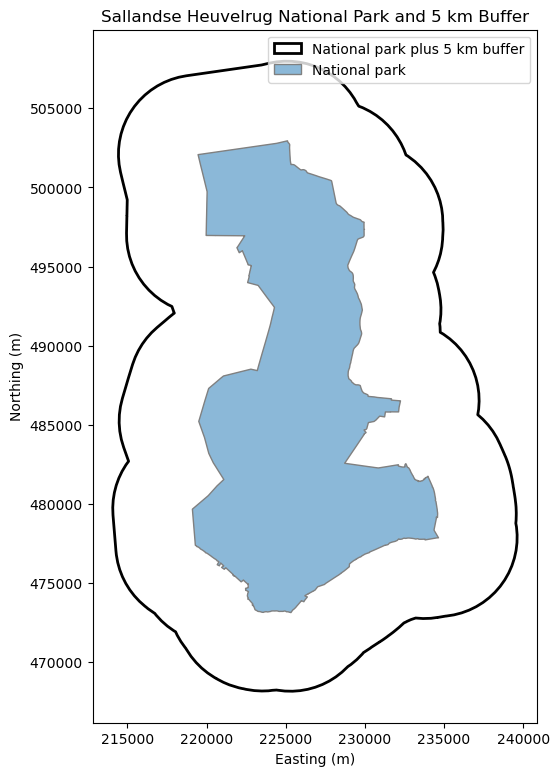

In [15]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 9))

buffer_5km.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2,
)

park_boundary.plot(
    ax=ax,
    facecolor="#8bb8d8",
    edgecolor="grey",
    linewidth=1,
)

legend_items = [
    Patch(
        facecolor="none",
        edgecolor="black",
        linewidth=2,
        label="National park plus 5 km buffer",
    ),
    Patch(
        facecolor="#8bb8d8",
        edgecolor="grey",
        label="National park",
    ),
]

ax.set_title("Sallandse Heuvelrug National Park and 5 km Buffer")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")
ax.legend(handles=legend_items)

plt.show()

In [16]:
park_area_km2 = park_boundary.geometry.area.sum() / 1_000_000
buffer_area_km2 = buffer_5km.geometry.area.sum() / 1_000_000

print(f"National park area: {park_area_km2:.2f} km²")
print(f"Buffered study area: {buffer_area_km2:.2f} km²")

National park area: 252.99 km²
Buffered study area: 762.89 km²
